In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Sector Momentum Rotation — Backtest

**Instrument:** 11 SPDR sector ETFs
**Signal:** Monthly, buy top 5 sectors by 6-month cumulative return.
**Rebalance:** Month-end.

88 trades, 56.8% WR, 143% return, -26.7% MaxDD from V2 screen.

Uses `shared/` for data, fees, metrics, significance, and results.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [2]:
STRATEGY_NAME = "Sector Momentum"
SAVE_NAME = "sector_momentum"

SECTORS = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLU", "XLB", "XLRE", "XLC"]
START_DATE = "2006-01-01"
END_DATE = "2026-04-01"
STARTING_CAPITAL = 100_000
TOP_N = 5
FORMATION = 126  # ~6 months

## 3. Data

In [3]:
data_dict = fetch_historical_data(SECTORS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

etf_data = {}
for t in SECTORS:
    if t not in data_dict:
        print(f"  {t}: NOT AVAILABLE — skipping")
        continue
    d = data_dict[t].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    etf_data[t] = d[["date", "close"]].sort_values("date").reset_index(drop=True)
    print(f"  {t}: {len(d):,} bars")

available = [t for t in SECTORS if t in etf_data]
price_df = etf_data[available[0]][["date"]].copy()
for t in available:
    price_df = price_df.merge(etf_data[t].rename(columns={"close": t}), on="date", how="inner")
price_df = price_df.sort_values("date").reset_index(drop=True)
print(f"\nCommon bars: {len(price_df):,}, Sectors: {len(available)}")

Fetching XLK...
  2,575 bars
Fetching XLF...
  2,575 bars
Fetching XLE...
  2,575 bars
Fetching XLV...
  2,575 bars
Fetching XLI...
  2,575 bars
Fetching XLY...
  2,575 bars
Fetching XLP...
  2,575 bars
Fetching XLU...
  2,575 bars
Fetching XLB...
  2,575 bars
Fetching XLRE...
  2,575 bars
Fetching XLC...
  1,956 bars
  XLK: 2,575 bars
  XLF: 2,575 bars
  XLE: 2,575 bars
  XLV: 2,575 bars
  XLI: 2,575 bars
  XLY: 2,575 bars
  XLP: 2,575 bars
  XLU: 2,575 bars
  XLB: 2,575 bars
  XLRE: 2,575 bars
  XLC: 1,956 bars

Common bars: 1,956, Sectors: 11


## 4. Backtest

In [4]:
price_df["ym"] = price_df["date"].dt.to_period("M")
rebal_idx = price_df.groupby("ym").tail(1).index.tolist()

equity = STARTING_CAPITAL
trades = []
holdings = {}

for idx in rebal_idx:
    row = price_df.iloc[idx]
    date = row["date"]
    if idx < FORMATION:
        continue
    
    past_row = price_df.iloc[max(0, idx - FORMATION)]
    returns = {}
    for t in available:
        if row[t] > 0 and past_row[t] > 0:
            returns[t] = row[t] / past_row[t] - 1
    
    ranked = sorted(returns.items(), key=lambda x: x[1], reverse=True)
    top = [t for t, r in ranked[:TOP_N]]
    
    # Close positions not in top
    for t in list(holdings.keys()):
        if t not in top:
            h = holdings[t]
            ep = row[t]
            gross = h["shares"] * (ep - h["entry_price"])
            fees = calculate_fees(h["shares"], h["entry_price"], ep, "long")
            net = gross - fees
            eq_before = equity
            equity += net
            trades.append({
                "entry_time": h["entry_date"], "exit_time": date,
                "position": "long",
                "entry_price": round(h["entry_price"], 4),
                "exit_price": round(ep, 4),
                "exit_reason": "rotation",
                "risk": round(h["entry_price"] * 0.05, 4),
                "shares": h["shares"],
                "gross_pnl": round(gross, 2),
                "fees": round(fees, 2),
                "net_pnl": round(net, 2),
                "equity_before": round(eq_before, 2),
                "equity": round(equity, 2),
            })
            del holdings[t]
    
    # Open new positions
    n_to_hold = min(TOP_N, len(top))
    if n_to_hold > 0:
        alloc_per = equity / n_to_hold
        for t in top:
            if t not in holdings:
                price = row[t]
                shares = int(alloc_per / price)
                if shares > 0:
                    holdings[t] = {"shares": shares, "entry_price": price, "entry_date": date}

# Close remaining
last = price_df.iloc[-1]
for t, h in list(holdings.items()):
    ep = last[t]
    gross = h["shares"] * (ep - h["entry_price"])
    fees = calculate_fees(h["shares"], h["entry_price"], ep, "long")
    net = gross - fees
    eq_before = equity
    equity += net
    trades.append({
        "entry_time": h["entry_date"], "exit_time": last["date"],
        "position": "long",
        "entry_price": round(h["entry_price"], 4),
        "exit_price": round(ep, 4),
        "exit_reason": "end_of_data",
        "risk": round(h["entry_price"] * 0.05, 4),
        "shares": h["shares"],
        "gross_pnl": round(gross, 2),
        "fees": round(fees, 2),
        "net_pnl": round(net, 2),
        "equity_before": round(eq_before, 2),
        "equity": round(equity, 2),
    })

results = pd.DataFrame(trades)
if not results.empty:
    results["entry_time"] = pd.to_datetime(results["entry_time"])
    results["exit_time"] = pd.to_datetime(results["exit_time"])
    results = results.sort_values("exit_time").reset_index(drop=True)
    eq = STARTING_CAPITAL
    for i in range(len(results)):
        results.loc[i, "equity_before"] = round(eq, 2)
        eq += results.loc[i, "net_pnl"]
        results.loc[i, "equity"] = round(eq, 2)

print(f"Total trades: {len(results)}")

Total trades: 93


## 5. Analysis

  Strategy             Sector Momentum
  Total Return             176.08%
  Annualized                10.15
  Max Drawdown             -22.79%
  Sharpe                     6.26
  Sortino                   16.43
  Profit Factor              3.47
  Trades               93
  Win Rate                  58.06%
  Avg Win              $    4,583.27
  Avg Loss             $   -1,831.19
  Long Trades          93
  Long PnL             $  176,080.40
  Long WR                   58.06%
  Short Trades         0
  Short PnL            0
  Short WR             0
  Total Fees           $    1,346.95
  Final Equity         $  276,080.40

Yearly Returns:
  2019: 16.01%
  2020: 0.0%
  2021: 44.78%
  2022: -2.54%
  2023: 11.78%
  2024: 19.28%
  2025: 5.62%
  2026: 6.96%


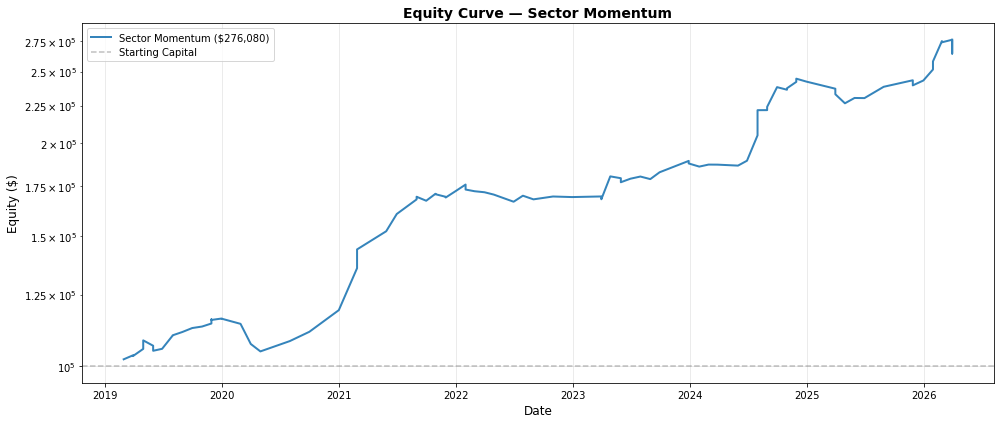

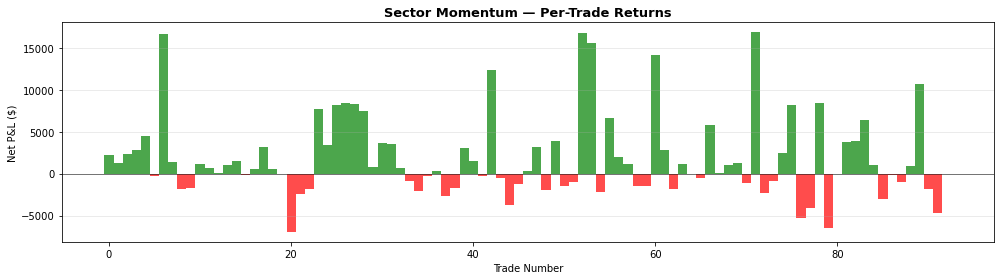

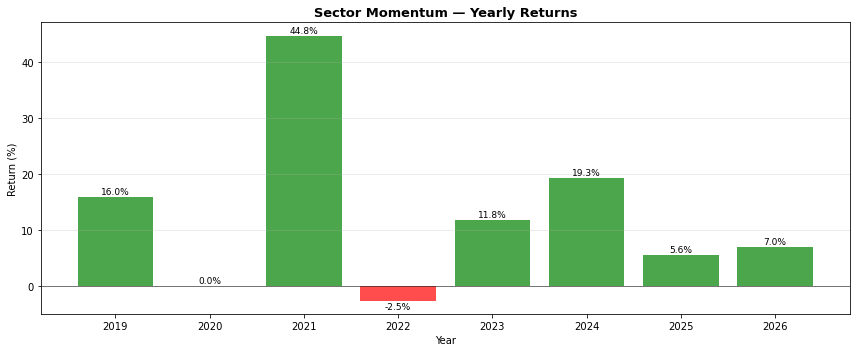


STATISTICAL SIGNIFICANCE — Sector Momentum

1. t-test (returns > 0)
   Mean return:  1.1376% per trade
   t-statistic:  3.8058
   p-value:      0.000127
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   6.2987
   95% CI:            [3.625, 8.9726]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   6.2987
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


In [5]:
if not results.empty:
    metrics = evaluate_strategy(results, STRATEGY_NAME)
    print_metrics(metrics)
    
    plot_equity_curve(results, label=STRATEGY_NAME, starting_capital=STARTING_CAPITAL)
    plot_trade_returns(results, title=f"{STRATEGY_NAME} — Per-Trade Returns")
    plot_yearly_returns(metrics, title=f"{STRATEGY_NAME} — Yearly Returns")
    
    if len(results) >= 5:
        report = full_significance_report(results, strategy_name=STRATEGY_NAME)
        print_significance_report(report)

## 6. Save

In [6]:
if not results.empty:
    save_trades(results, SAVE_NAME)

Saved 93 trades → results\sector_momentum_trades.csv
